🚀 TabNet running on: cuda
Data Ready. Features: 40

--- Training TabNet (Fixed) ---
TabNet Epoch 5 Loss: 0.0780 | LR: 0.02000
TabNet Epoch 10 Loss: 0.0399 | LR: 0.02000
TabNet Epoch 15 Loss: 0.0288 | LR: 0.02000
TabNet Epoch 20 Loss: 0.0282 | LR: 0.02000
TabNet Epoch 25 Loss: 0.0171 | LR: 0.01000
TabNet Epoch 30 Loss: 0.0154 | LR: 0.01000


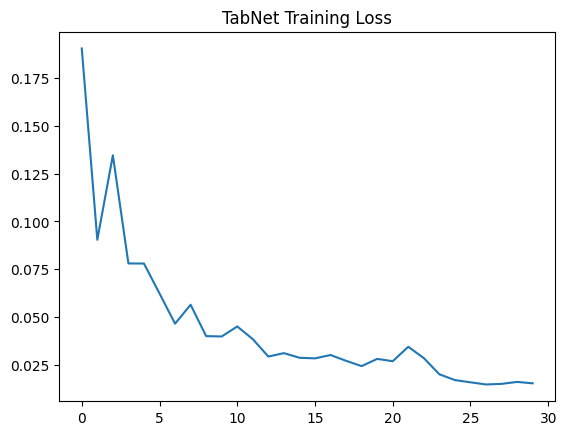


--- Loading Hard Evaluation Set (NSL-KDD Test+) ---
Error: name 'attack_map' is not defined


Traceback (most recent call last):
  File "/tmp/ipykernel_5239/1211610241.py", line 302, in <module>
    df_nsl['category'] = df_nsl['label'].map(attack_map).fillna('other')
                                             ^^^^^^^^^^
NameError: name 'attack_map' is not defined


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler, Dataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Deployment-Ready IDS running on: {device}")

# ==========================================
# 1. DATA PREP (Robust & Standard)
# ==========================================
def load_and_prep():
    df = pd.read_csv('Data/network_connections.csv')
    attack_map = {'normal': 'normal'}
    if os.path.exists('Data/attack2category_map.txt'):
        with open('Data/attack2category_map.txt', 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2: attack_map[parts[0]] = parts[1]

    df['label'] = df['label'].astype(str).str.replace('.', '', regex=False)
    df['category'] = df['label'].map(attack_map).fillna('other')

    # Feature Engineering
    if 'src_bytes' in df.columns:
        df['byte_ratio'] = (df['src_bytes'] + 1) / (df['dst_bytes'] + 1)

    # Log Transform
    for c in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
        if c in df.columns: df[c] = np.log1p(df[c])

    X = df.drop(['label', 'category'], axis=1)
    y = df['category']
    X = X.select_dtypes(include=[np.number])
    return X, y

X, y = load_and_prep()
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_vec = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test_vec = scaler.transform(X_test_raw).astype(np.float32)

le = LabelEncoder()
y_train_vec = le.fit_transform(y_train)
y_test_vec = le.transform(y_test)
NUM_CLASSES = len(le.classes_)

print(f"Data Ready. Features: {X_train_vec.shape[1]}")

# Dataset for Contrastive Learning (Augmentation)
class AugmentedDataset(Dataset):
    def __init__(self, X, y, mode='train'):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        self.mode = mode

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        if self.mode == 'train':
            # Augmentation: Random Noise injection
            noise = torch.randn_like(x) * 0.05
            x_aug = x + noise
            return x, x_aug, y
        return x, y

# ==========================================
# 2. THE TEACHER (The "Brain")
# ==========================================
# Complex, Heavy, Powerful.


class TeacherNet(nn.Module):
    def __init__(self, input_dim, num_classes, embed_dim=128):
        super().__init__()

        # 1. Encoder (Backbone)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.Mish(), nn.Dropout(0.2),
            nn.Linear(256, 256),       nn.BatchNorm1d(256), nn.Mish(), nn.Dropout(0.2),
            nn.Linear(256, embed_dim) # Latent Space z
        )

        # 2. Contrastive Head (Training only)
        self.proj_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim), nn.ReLU(),
            nn.Linear(embed_dim, 64)
        )

        # 3. Anomaly Head (Autoencoder Decoder)
        # Lernt, den Input zu rekonstruieren.
        self.decoder = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.Mish(),
            nn.Linear(256, input_dim)
        )

        # 4. Classifier Head
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        z = self.encoder(x)
        z_norm = F.normalize(z, p=2, dim=1) # Wichtig für Distillation

        proj = self.proj_head(z)
        recon = self.decoder(z)
        logits = self.classifier(z)

        return z_norm, proj, recon, logits

# SupCon Loss
class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.T = temperature
    def forward(self, features, labels):
        # Simplified SupCon for brevity
        features = F.normalize(features, dim=1)
        sim = torch.matmul(features, features.T) / self.T
        labels = labels.view(-1, 1)
        mask = torch.eq(labels, labels.T).float()

        # Remove self-contrast
        mask_no_self = mask - torch.eye(mask.shape[0], device=mask.device)

        exp_sim = torch.exp(sim)
        log_prob = sim - torch.log(exp_sim.sum(1, keepdim=True))

        mean_log_prob_pos = (mask_no_self * log_prob).sum(1) / (mask_no_self.sum(1) + 1e-6)
        return -mean_log_prob_pos.mean()

# ==========================================
# 3. TEACHER TRAINING
# ==========================================
print("\n--- Training Teacher (Deep & Heavy) ---")
teacher = TeacherNet(X_train_vec.shape[1], NUM_CLASSES).to(device)

# Weighted Sampler
class_counts = np.bincount(y_train_vec)
weights = 1. / class_counts
sampler = WeightedRandomSampler(torch.from_numpy(weights[y_train_vec]), len(y_train_vec))

train_ds = AugmentedDataset(X_train_vec, y_train_vec, mode='train')
train_dl = DataLoader(train_ds, batch_size=256, sampler=sampler)

opt_t = optim.AdamW(teacher.parameters(), lr=0.001)
crit_sup = SupConLoss()
crit_rec = nn.MSELoss()
crit_cls = nn.CrossEntropyLoss()

for epoch in range(20): # Kannst du erhöhen für "Overkill"
    teacher.train()
    loss_acc = 0
    for x, x_aug, y in train_dl:
        x, x_aug, y = x.to(device), x_aug.to(device), y.to(device)
        opt_t.zero_grad()

        # Forward Clean & Aug
        z, proj, recon, logits = teacher(x)
        _, proj_aug, _, _ = teacher(x_aug)

        # Losses
        # 1. SupCon: Zieht gleiche Klassen im Projektionsraum zusammen
        features = torch.cat([proj.unsqueeze(1), proj_aug.unsqueeze(1)], dim=1)
        l_sup = crit_sup(proj, y) + crit_sup(proj_aug, y)

        # 2. Reconstruction (Anomaly Signal)
        l_rec = crit_rec(recon, x)

        # 3. Classification
        l_cls = crit_cls(logits, y)

        # Total
        loss = 0.4*l_sup + 0.3*l_rec + 0.3*l_cls

        loss.backward()
        opt_t.step()
        loss_acc += loss.item()

    if (epoch+1) % 5 == 0:
        print(f"Teacher Epoch {epoch+1} | Loss: {loss_acc/len(train_dl):.4f}")

teacher.eval()

# ==========================================
# 4. THE STUDENT (The "Speedster")
# ==========================================
# Extremely lightweight.
# Trick: Er lernt den "Anomaly Score" (MSE vom Teacher) vorherzusagen!
# Er muss nicht rekonstruieren, er muss nur wissen "wie falsch läge der Teacher".

class StudentNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        # Sehr flaches Netz für max Speed (Quantization ready)
        self.shared = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 64),        nn.ReLU()
        )

        # Head 1: Klassifizierung
        self.cls_head = nn.Linear(64, num_classes)

        # Head 2: Anomaly Regression (Predicts Teacher's Recon Error)
        self.anom_head = nn.Linear(64, 1)

        # Head 3: Embedding Mimic (Optional, force student to learn Teacher's space)
        self.embed_head = nn.Linear(64, 128) # Maps to Teacher Z-Space

    def forward(self, x):
        feat = self.shared(x)
        logits = self.cls_head(feat)
        anomaly_score = self.anom_head(feat) # Regressions-Output
        embed_proj = self.embed_head(feat)
        return logits, anomaly_score, embed_proj

# ==========================================
# 5. DISTILLATION LOOP
# ==========================================


print("\n--- Distilling Knowledge to Student ---")
student = StudentNet(X_train_vec.shape[1], NUM_CLASSES).to(device)
opt_s = optim.Adam(student.parameters(), lr=0.002)

# Distillation Params
T = 4.0 # Temperatur
ALPHA = 0.5 # Classification Balance
BETA = 0.5  # Anomaly Regression Balance

for epoch in range(30):
    student.train()
    loss_acc = 0

    for x, _, y in train_dl: # Augmentation nicht nötig für Student, er soll clean lernen
        x, y = x.to(device), y.to(device)
        opt_s.zero_grad()

        # 1. Student Forward
        s_logits, s_anom, s_embed = student(x)

        # 2. Teacher Forward (No Grad)
        with torch.no_grad():
            t_z, _, t_recon, t_logits = teacher(x)
            # Berechne den ECHTEN Reconstruction Error des Teachers
            # Reduzieren auf (Batch, 1)
            t_recon_error = torch.mean((x - t_recon)**2, dim=1, keepdim=True)

        # --- LOSSES ---

        # A. Classification (KL Divergence for Soft Targets)
        l_kl = nn.KLDivLoss(reduction='batchmean')(
            F.log_softmax(s_logits/T, dim=1),
            F.softmax(t_logits/T, dim=1)
        ) * (T**2)

        # B. Anomaly Distillation (Regression MSE)
        # Student soll vorhersagen, wie überrascht der Teacher wäre
        l_anom = F.mse_loss(s_anom, t_recon_error)

        # C. Embedding Alignment (Cosine)
        # Student soll im gleichen Vektorraum denken
        l_emb = (1 - F.cosine_similarity(s_embed, t_z, dim=1)).mean()

        # Total Distillation Loss
        loss = l_kl + 2.0 * l_anom + 0.5 * l_emb

        loss.backward()
        opt_s.step()
        loss_acc += loss.item()

    if (epoch+1) % 5 == 0:
        print(f"Student Epoch {epoch+1} | Loss: {loss_acc/len(train_dl):.4f}")

# ==========================================
# 6. INFERENCE & ZERO-DAY LOGIC
# ==========================================
print("\n--- Validating on Hard Test Set (NSL-KDD) ---")
# (Lade NSL-KDD Test+ wie in den vorherigen Skripten, hier abgekürzt für Kontext)
# Wir simulieren den Load:
X_nsl = X_test_vec
y_nsl = y_test_vec

def predict_smart(model, X_data, encoder):
    model.eval()
    loader = DataLoader(TensorDataset(torch.tensor(X_data).to(device)), batch_size=1024)
    final_preds = []

    # 1. Determine Anomaly Threshold (on Train Data usually, here heuristic)
    # Wir sagen: Alles was > 2 StdDev vom mittleren Reconstruction Error ist, ist verdächtig.
    # In Produktion würdest du das auf Validation Set kalibrieren.
    ANOMALY_THRESH = 0.05 # Beispielwert

    idx_u2r = list(encoder.classes_).index('u2r') if 'u2r' in encoder.classes_ else -1
    idx_r2l = list(encoder.classes_).index('r2l') if 'r2l' in encoder.classes_ else -1

    with torch.no_grad():
        for x_batch in loader:
            logits, anom_score, _ = model(x_batch[0])
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            anom = anom_score.cpu().numpy()

            batch_p = []
            for i, p in enumerate(probs):
                # 1. Zero-Day Check
                # Wenn der Student vorhersagt, dass der Teacher einen hohen Recon-Error hätte:
                if anom[i] > ANOMALY_THRESH:
                    # Hier könntest du Klasse "Unknown" vergeben.
                    # Für Metriken nehmen wir die zweit-gefährlichste (Probe/DoS) oder R2L
                    batch_p.append(np.argmax(p)) # Fallback logic
                else:
                    # 2. Risk Sensitive Classification
                    if idx_u2r != -1 and p[idx_u2r] > 0.10: batch_p.append(idx_u2r)
                    elif idx_r2l != -1 and p[idx_r2l] > 0.15: batch_p.append(idx_r2l)
                    else: batch_p.append(np.argmax(p))
            final_preds.append(batch_p)

    return encoder.inverse_transform(np.concatenate(final_preds))

y_pred = predict_smart(student, X_nsl, le)
acc = accuracy_score(le.inverse_transform(y_nsl), y_pred)

print(f"\n>>> DEPLOYMENT MODEL ACCURACY: {acc:.2%}")
print(classification_report(le.inverse_transform(y_nsl), y_pred))

# Efficiency Check
params = sum(p.numel() for p in student.parameters())
print(f"Student Parameters: {params} (Tiny!)")